# Spatially Variable Ocean Dynamics

This notebook introduces a prior model for ocean dynamic topography (ODT) and sea surface height (SSH) variability not attributable to ice-sheet-driven sea level change.

We construct a Gaussian measure for ocean dynamics using a rotationally invariant Sobolev kernel, scaled by a spatial weight field (e.g., derived from observed DUACS SSH variability).


## Setup

Similar to the ice sheets and firn models, we use a global spherical harmonic model bounded to the oceans to define ocean dynamics variability.


In [1]:
import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np

from pyslfp import FingerPrint, IceModel
from pyslfp_extras import plot
from pyslfp_extras.ocean_dynamics import OceanDynamics
from project import colors

np.random.seed(423991)

lmax = 256
fp = FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

## Uniform Ocean Dynamics

First, we generate a uniform, spatially invariant variance field over the ocean domain.


Text(0.5, 1.0, 'Sample from Uniform Ocean Dynamics Prior')

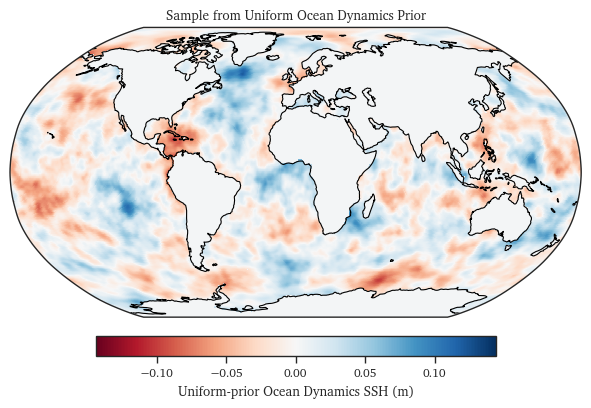

In [2]:
od_uniform = OceanDynamics(
    finger_print=fp,
    finger_print_operator=fp_op,
    std=0.03,  # Target std of SSH variability in m
    length_scale=0.01 * fp.mean_sea_floor_radius,
    pattern=OceanDynamics.UniformPattern(),
)

uniform_ssh_measure = od_uniform.ssh_measure
uniform_sample = uniform_ssh_measure.sample()

fig, ax, _ = plot(
    uniform_sample,
    symmetric=True,
    colorbar_label="Uniform-prior Ocean Dynamics SSH (m)",
)
ax.set_title("Sample from Uniform Ocean Dynamics Prior")

## Observation-based Spatial Variability

A uniform measure fails to capture the significant spatial variations present in observed sea surface height. We can use altimeter observations (for instance, the variance in monthly gridded sea level anomalies from AVISO/DUACS) to pattern the variability.

This defines a weight field that scales the local standard deviation to match the spatial pattern seen in nature: high variability in the Southern Ocean and western boundary currents, and lower variability in the gyres.

Text(0.5, 1.0, 'Data-derived SSH Variability Pattern')

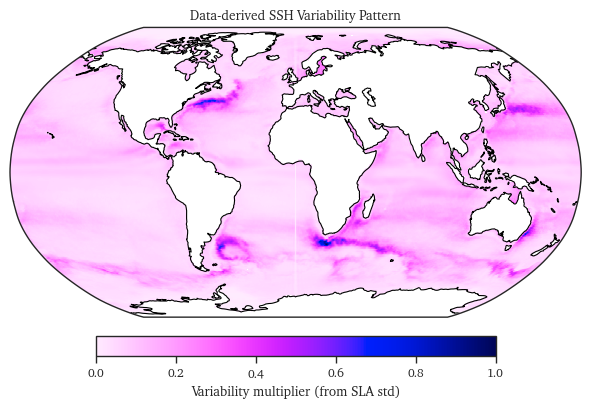

In [3]:
data_pattern = OceanDynamics.DataPattern()
field = data_pattern.spatial_field(fp)

fig, ax, _ = plot(
    field * fp.ocean_projection(),
    colorbar_label="Variability multiplier (from SLA std)",
    cmap=cc.cm.bmw_r,
)
ax.set_title("Data-derived SSH Variability Pattern")

We can now generate a random realisation of ocean dynamics SSH anomalies scaled by this observation-based pattern.

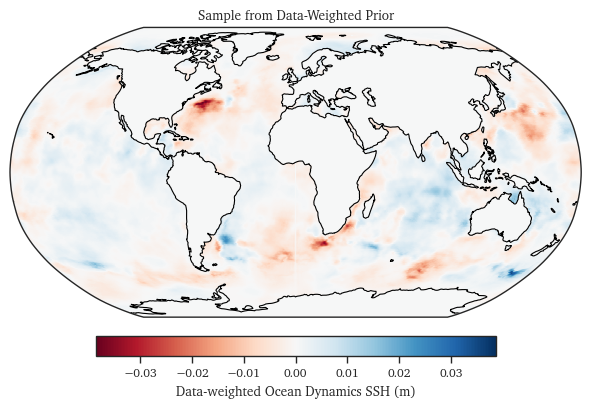

In [4]:
od_data = OceanDynamics(
    finger_print=fp,
    finger_print_operator=fp_op,
    std=0.03,  # Target std of SSH variability in m
    length_scale=0.01 * fp.mean_sea_floor_radius,
    pattern=data_pattern,
)

data_ssh_measure = od_data.ssh_measure
data_sample = data_ssh_measure.sample()

max_val = np.max(np.abs(data_sample.data))

fig, ax, _ = plot(
    data_sample,
    symmetric=True,
    vmax=max_val,
    vmin=-max_val,
    colorbar_label="Data-weighted Ocean Dynamics SSH (m)",
)
ax.set_title("Sample from Data-Weighted Prior")
plt.show()